In [38]:
# Mount into drive

from google.colab import drive
import matplotlib.pyplot as plt

drive.mount("/content/drive")

%cd '/content/drive/MyDrive/CS7643/FinalProject/Finalpipeline/'


# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CS7643/FinalProject/Finalpipeline
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import os
import time
import yaml
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
!pip install torchmetrics
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score
from sklearn.metrics import confusion_matrix
from dataloader import DataLoader as MyLoader
import torchvision
import copy
import random

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)


In [40]:
with open('config_vit.yaml', 'r') as file:
    cfg = yaml.safe_load(file)
print(cfg)

{'input_size': 224, 'model': {'name': 'vit_b_16', 'pretrained': True, 'num_classes': 20, 'freeze_base': True}, 'train': {'batch_size': 512, 'epochs': 30, 'lr': 0.0001, 'optimizer': 'adam', 'weight_decay': 0.0005, 'val_split': 0.15, 'test_split': 0.15, 'seed': 42}}


In [41]:
from vit_b_16 import get_model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# freeze_base = True #False # for non pre trained
# model = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1)
# #model = torchvision.models.vit_b_16()

# model.to(device)
# for name, param  in  model.named_parameters():
#     if "head" not in name:
#       # freeze all except the final layer
#       param.requires_grad = not freeze_base

# full_model = torch.nn.Sequential(
#     model,
#     torch.nn.Dropout(0.5),
#     torch.nn.Linear(model.heads.head.out_features, 32),
#     torch.nn.ReLU(),
#     torch.nn.Linear(32, cfg['model']['num_classes'])
# )
model = get_model(num_classes = cfg['model']['num_classes'], pretrained=True, freeze_base=True)
model.to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 182MB/s]


Sequential(
  (0): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): LayerNor

Testing download...


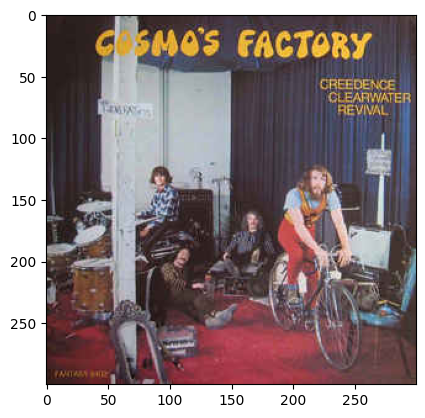

Converting data to tensors...
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Verifying processing...


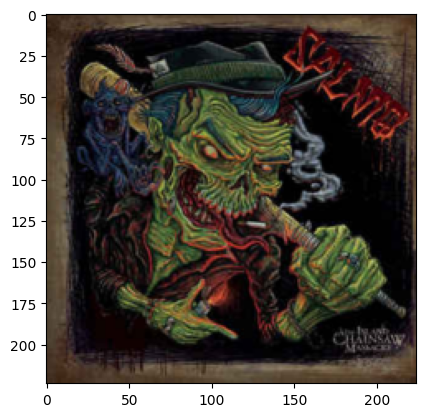

In [42]:
dl = MyLoader(cfg)
dl.main()

train_x, train_y = dl.return_train_data()
val_x, val_y = dl.return_val_data()
test_x, test_y = dl.return_test_data()

train_dataset = TensorDataset(train_x, train_y.squeeze(1).long())
val_dataset = TensorDataset(val_x, val_y.squeeze(1).long())
test_dataset = TensorDataset(test_x, test_y.squeeze(1).long())
# cfg['train']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=cfg['train']['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg['train']['batch_size'])
test_loader = DataLoader(test_dataset, batch_size=cfg['train']['batch_size'])

In [43]:
label_names = dl.labelNames
del dl

In [44]:
print(label_names)

{0: 'blues', 1: 'classical', 2: 'country', 3: 'deathmetal', 4: 'doommetal', 5: 'drumnbass', 6: 'electronic', 7: 'folk', 8: 'grime', 9: 'heavymetal', 10: 'hiphop', 11: 'jazz', 12: 'lofi', 13: 'pop', 14: 'psychedelicrock', 15: 'punk', 16: 'reggae', 17: 'rock', 18: 'soul', 19: 'techno'}


In [45]:
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg['train']['lr'], weight_decay=cfg['train']['weight_decay'])


In [46]:
#folder_name = f"{cfg['model']['name']}_freeze={cfg['model']['freeze_base']}_{int(time.time())}"
folder_name = "vit_b_16"
save_dir = os.path.join('checkpoints', folder_name)
os.makedirs(save_dir, exist_ok=True)

In [47]:
train_losses = []
val_losses = []
val_accuracies = []
tr_accuracies = []
best_val_loss = float('inf')
early_stop_counter = 0
best_model = None

for epoch in range(cfg['train']['epochs']):
    model.train()
    tr_accuracy = MulticlassAccuracy(num_classes=cfg['model']['num_classes']).to(device)
    total_loss = 0
    count = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        tr_accuracy.update(outputs, labels)
        count += 1
    if (epoch + 1) % 10 == 0:
      optimizer.param_groups[0]['lr'] *= 0.75
      optimizer.param_groups[0]['weight_decay'] *= 1.25
    total_loss /= count
    train_losses.append(total_loss)
    acc = tr_accuracy.compute().item() * 100
    tr_accuracies.append(acc)

    # Validation
    model.eval()
    val_accuracy = MulticlassAccuracy(num_classes=cfg['model']['num_classes']).to(device)
    with torch.no_grad():
        val_loss = 0
        count = 0
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            outputs = model(val_images)
            loss = criterion(outputs, val_labels)
            val_loss += loss.item()
            val_accuracy.update(outputs, val_labels)
            count += 1
        val_loss /= count
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model)
    acc = val_accuracy.compute().item() * 100
    val_accuracies.append(acc)

    print(f"\nEpoch [{epoch+1}/{cfg['train']['epochs']}], Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {acc:.2f}%")

torch.save(best_model.state_dict(), os.path.join(save_dir, 'pretr_2lin_128_best_checkpoint_vit_b_16_512_30.pt'))



Epoch [1/30], Train Loss: 2.9941, Val Loss: 2.9381, Val Acc: 11.19%

Epoch [2/30], Train Loss: 2.9147, Val Loss: 2.8567, Val Acc: 15.09%

Epoch [3/30], Train Loss: 2.8388, Val Loss: 2.7834, Val Acc: 17.52%

Epoch [4/30], Train Loss: 2.7770, Val Loss: 2.7319, Val Acc: 18.53%

Epoch [5/30], Train Loss: 2.7266, Val Loss: 2.6975, Val Acc: 19.68%

Epoch [6/30], Train Loss: 2.6863, Val Loss: 2.6706, Val Acc: 19.87%

Epoch [7/30], Train Loss: 2.6583, Val Loss: 2.6513, Val Acc: 20.67%

Epoch [8/30], Train Loss: 2.6366, Val Loss: 2.6364, Val Acc: 21.48%

Epoch [9/30], Train Loss: 2.6170, Val Loss: 2.6225, Val Acc: 22.33%

Epoch [10/30], Train Loss: 2.5963, Val Loss: 2.6144, Val Acc: 22.42%

Epoch [11/30], Train Loss: 2.5788, Val Loss: 2.6075, Val Acc: 23.24%

Epoch [12/30], Train Loss: 2.5720, Val Loss: 2.6006, Val Acc: 23.28%

Epoch [13/30], Train Loss: 2.5523, Val Loss: 2.5950, Val Acc: 24.06%

Epoch [14/30], Train Loss: 2.5464, Val Loss: 2.5883, Val Acc: 24.08%

Epoch [15/30], Train Loss: 2

In [49]:
print(best_val_loss)
print(max(val_accuracies))

2.5509109099706015
26.162827014923096



Test Accuracy: 24.38%
Test Precision: 22.88%
Test Recall: 24.38%
Test F1 Score: 23.14%


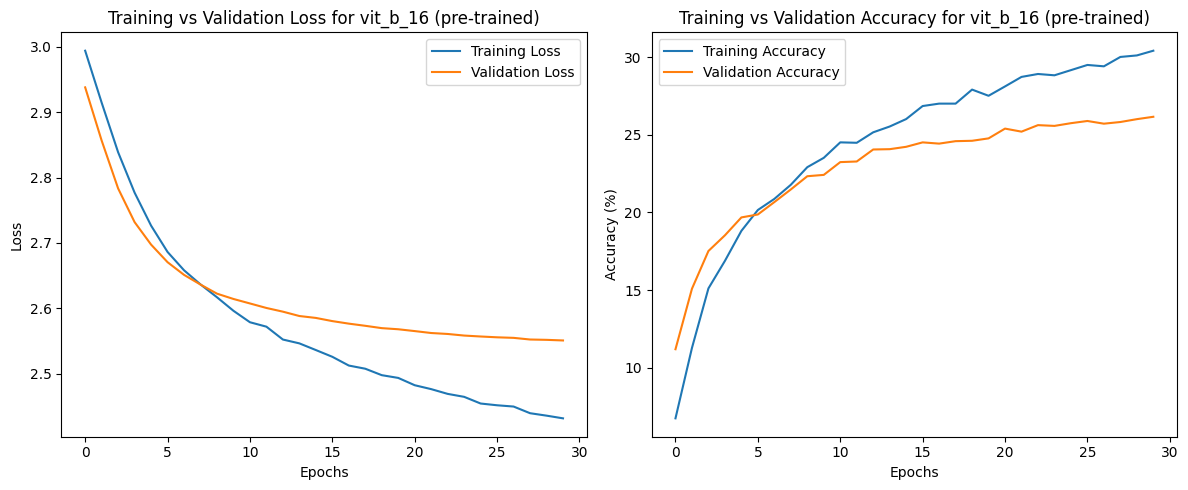


Confusion Matrix:
[[ 8  9 12  3  7  4  5 13  3  4  6 10  9  5  6 12 11  7 13  6]
 [ 3 92  5  5  6  4  4  8  1  3  2 10  4  2  3  6  3  0  4  3]
 [ 8 20 37  3  6  1  1 14  2  2  7  6  3 13  4  5  4  5 18  2]
 [ 0  3  0 73 26  1  1  0  2 12  3  0  1  0  0  6  0  0  2  2]
 [ 0  6  0 33 50  3  4  6  6 12  1  2 10  2  3  8  1  2  1  2]
 [ 2  6  0  7  7 36  2  3 12  8  5  5  5  3  2  4  5  4  1 26]
 [ 0  6  5  6  7 12 17  4  7  8 12  8  6 19  6  4  2  3  8 15]
 [13 21 13  2 12  8  2 17  3  2  3  7  9  9  3  5  6  5  6  1]
 [ 0  6  0  6  8 16  4  2 53  1  9  2  9  3  5  4  3  1  0 16]
 [ 2  6  2 31  9  3  3  3  6 54  4  1  3  1  1 10  3  3  0  2]
 [ 3  2  4  6  3  8  5  1  6 19 30  7  9  9  5  9 11  0 12  8]
 [ 3 13  5  2  3  2  4  8  3  7  7 28  4  6  3  4  3  4 11  2]
 [ 2  9  1 12 10  9  3  7  3  2  8  5 34  6  3 13  5  2  1  8]
 [ 8  8  6  1  2  3 11  8  2  5 11  6  7 20  9  5  2  5  6  2]
 [ 7  7  4  5 10  8  6 13  3  8  3 10  7  4 32  7  7  8  6  5]
 [ 2  4  3  8  8  2  7  8  4 10  8 1

In [56]:
model.load_state_dict(torch.load(os.path.join(save_dir, 'pretr_2lin_128_best_checkpoint_vit_b_16_512_30.pt')))
model.eval()

all_test_preds, all_test_labels = [], []
test_accuracy = MulticlassAccuracy(num_classes=cfg['model']['num_classes']).to(device)
test_precision = MulticlassPrecision(num_classes=cfg['model']['num_classes'], average='macro').to(device)
test_recall = MulticlassRecall(num_classes=cfg['model']['num_classes'], average='macro').to(device)
test_f1 = MulticlassF1Score(num_classes=cfg['model']['num_classes'], average='macro').to(device)

with torch.no_grad():
    for test_images, test_labels in test_loader:
        test_images, test_labels = test_images.to(device), test_labels.to(device)
        outputs = model(test_images)
        test_accuracy.update(outputs, test_labels)
        test_precision.update(outputs, test_labels)
        test_recall.update(outputs, test_labels)
        test_f1.update(outputs, test_labels)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(test_labels.cpu().numpy())

print(f"\nTest Accuracy: {test_accuracy.compute().item()*100:.2f}%")
print(f"Test Precision: {test_precision.compute().item()*100:.2f}%")
print(f"Test Recall: {test_recall.compute().item()*100:.2f}%")
print(f"Test F1 Score: {test_f1.compute().item()*100:.2f}%")

model_name = "vit_b_16 (pre-trained)"
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for ' + model_name)
plt.legend()

plt.subplot(1,2,2)
plt.plot(tr_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs');
plt.ylabel('Accuracy (%)');
plt.title('Training vs Validation Accuracy for '+model_name)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "FINALSUB_PRETR_loss_accuracy_plot_val_train " +model_name+ ".png"), dpi=300)
plt.show()

cm = confusion_matrix(all_test_labels, all_test_preds)
print("\nConfusion Matrix:")
print(cm)

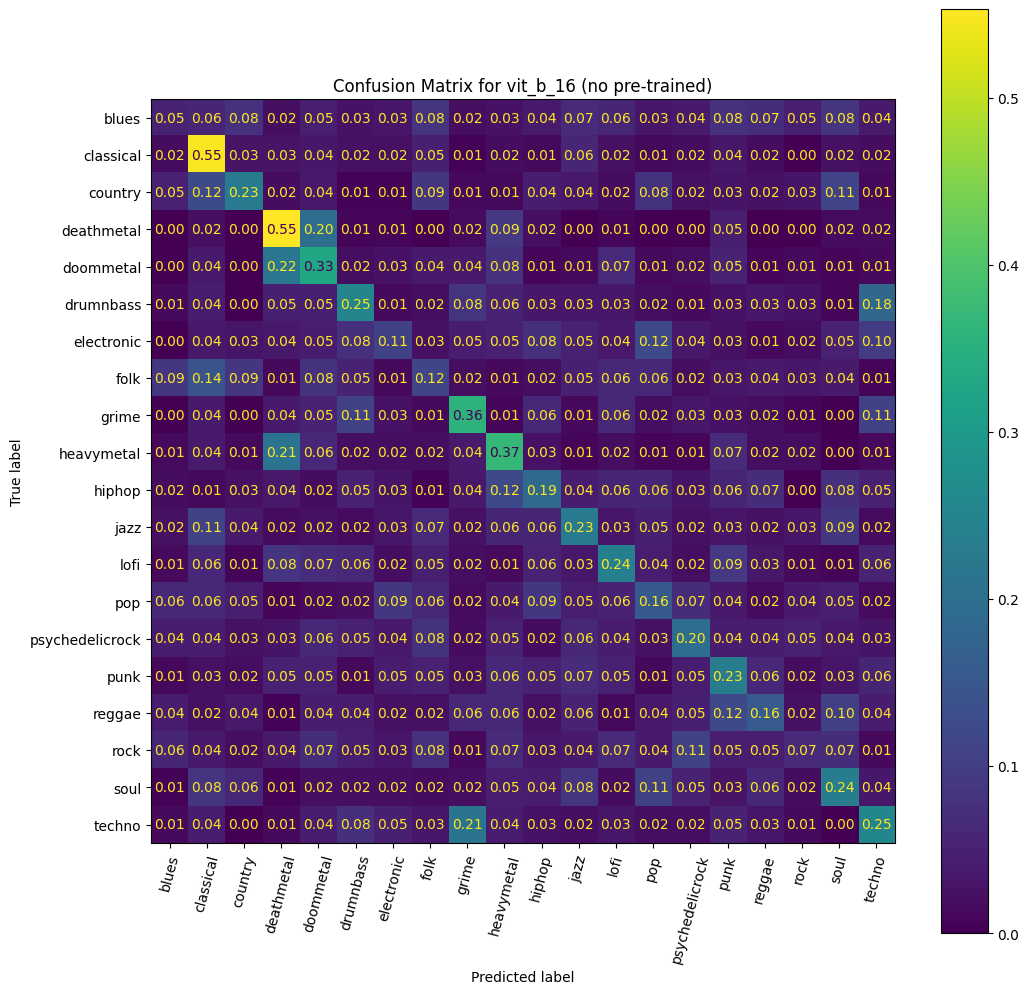

In [52]:
import sklearn

fig, ax = plt.subplots(figsize=(12, 12))
cm = confusion_matrix(all_test_labels, all_test_preds, normalize='true')
x = sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels=label_names.values())
x.plot(ax=ax, values_format='.2f')
plt.xticks(rotation=75)
plt.title("Confusion Matrix for " + model_name)
plt.show()
# plt.savefig(os.path.join(save_dir, "confusion_matrix_ " +model_name+ ".png"), dpi=600)

In [54]:
print(label_names)

{0: 'blues', 1: 'classical', 2: 'country', 3: 'deathmetal', 4: 'doommetal', 5: 'drumnbass', 6: 'electronic', 7: 'folk', 8: 'grime', 9: 'heavymetal', 10: 'hiphop', 11: 'jazz', 12: 'lofi', 13: 'pop', 14: 'psychedelicrock', 15: 'punk', 16: 'reggae', 17: 'rock', 18: 'soul', 19: 'techno'}


In [53]:
# per class accuracy
print(np.diag(cm/np.sum(cm, axis=1)))

[0.05228758 0.54761905 0.22981366 0.5530303  0.32894737 0.25174825
 0.10967742 0.11564626 0.35810811 0.36734694 0.1910828  0.2295082
 0.23776224 0.15748031 0.2        0.23225806 0.1595092  0.06622517
 0.23529412 0.25342466]


In [ ]:
# for name, param in model.named_parameters():
#     if "head" not in name and "conv_proj" not in name:
#       print(name)

In [ ]:
"""
VIT_B_16 MODEL
plus
nn.Dropout(0.5),
    torch.nn.Linear(model.heads.head.out_features, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, cfg['model']['num_classes'])

batch size 32
epochs 30
lr 0.0001 (*=0.75 every 10)
weight decay 0.0005 (*=1.25 every 10)

no pretraining
Test Accuracy: 10.35%
Test Precision: 8.71%
Test Recall: 10.35%
Test F1 Score: 8.24%
2.9105094721976745 best val loss
9.6190445125103 max val acc
Confusion Matrix:
[[ 6  5 13 24 13  5  1 14  4 17  0  0 18  2  3 10  6  0  8  4]
 [ 3 21 13 24 10  0  1 11  3 11  0  0 35  3  4  9  4  0 13  3]
 [ 6 15 19 32 14  2  1  8  4  5  0  0 16  0  4 14  5  1 13  2]
 [ 4  7  8 49 23  3  0  2  4 19  0  0  4  0  1  3  0  0  4  1]
 [ 3  5  8 27 42  4  1  7  6 15  0  0 12  0  1  5  1  0  9  6]
 [ 2  8  8 22 21  3  3  4 16  9  0  0 13  2  0  3 12  0  3 14]
 [ 1  7  6 21 15  3  2  4  5 14  0  0 42  1  0 11  7  0  7  9]
 [ 9  5 15 27 19  2  0 16  3  2  0  0 30  0  4  4  4  0  7  0]
 [ 2  6  4 11 21  0  0  5 22  5  0  0 31  1  0 15  9  0  3 13]
 [ 2  8 10 46 16  3  1  1  2 28  0  0  8  1  1  6  5  0  7  2]
 [ 8 10 13 20 10  3  2  8  7 21  0  0 13  1  4 15 12  0  7  3]
 [ 4 10  9 33 10  3  0  5  2  7  0  0 20  0  0  8  3  0  4  4]
 [ 4  8 10 16 15  2  0  8  4  5  0  0 37  1  4  7  6  0  8  8]
 [ 4  8  7 18  4  0  2  5  6  9  0  0 34  1  2  8  5  0 12  2]
 [ 7 10 12 21 16  3  2 10  3 16  0  0 27  0  8 10  5  1  4  5]
 [ 2  5 11 29 15  3  1  6  6 14  0  0 25  1  4 11 14  0  5  3]
 [ 2 10 12 11 10  3  1 10  4 18  0  0 30  1  6 17 12  0 11  5]
 [ 4  8 16 27 15  2  1  6  3 15  0  0 24  1  3  9  7  0  5  5]
 [ 5 15 23 24 14  5  0 13  2 20  0  0 18  2  3  6  7  0  9  4]
 [ 6  2  4 11 19  3  2  7 13  6  0  0 22  1  1 10 14  0  4 21]]

per class accuracy
[0.03921569 0.125      0.11801242 0.37121212 0.27631579 0.02097902
 0.01290323 0.10884354 0.14864865 0.19047619 0.         0.
 0.25874126 0.00787402 0.05       0.07096774 0.07361963 0.
 0.05294118 0.14383562]

Epoch [1/30], Train Loss: 3.0015, Val Loss: 2.9970, Val Acc: 4.89%

Epoch [2/30], Train Loss: 2.9944, Val Loss: 2.9796, Val Acc: 7.00%

Epoch [3/30], Train Loss: 2.9786, Val Loss: 2.9677, Val Acc: 7.36%

Epoch [4/30], Train Loss: 2.9745, Val Loss: 2.9762, Val Acc: 6.94%

Epoch [5/30], Train Loss: 2.9701, Val Loss: 2.9741, Val Acc: 6.91%

Epoch [6/30], Train Loss: 2.9674, Val Loss: 2.9759, Val Acc: 7.70%

Epoch [7/30], Train Loss: 2.9622, Val Loss: 2.9578, Val Acc: 7.65%

Epoch [8/30], Train Loss: 2.9567, Val Loss: 2.9486, Val Acc: 8.24%

Epoch [9/30], Train Loss: 2.9498, Val Loss: 2.9497, Val Acc: 7.56%

Epoch [10/30], Train Loss: 2.9475, Val Loss: 2.9868, Val Acc: 7.09%

Epoch [11/30], Train Loss: 2.9405, Val Loss: 2.9486, Val Acc: 7.72%

Epoch [12/30], Train Loss: 2.9383, Val Loss: 2.9494, Val Acc: 7.64%

Epoch [13/30], Train Loss: 2.9347, Val Loss: 2.9307, Val Acc: 9.43%

Epoch [14/30], Train Loss: 2.9303, Val Loss: 2.9370, Val Acc: 8.35%

Epoch [15/30], Train Loss: 2.9271, Val Loss: 2.9339, Val Acc: 8.84%

Epoch [16/30], Train Loss: 2.9215, Val Loss: 2.9226, Val Acc: 8.64%

Epoch [17/30], Train Loss: 2.9186, Val Loss: 2.9232, Val Acc: 9.19%

Epoch [18/30], Train Loss: 2.9141, Val Loss: 2.9154, Val Acc: 9.09%

Epoch [19/30], Train Loss: 2.9095, Val Loss: 2.9203, Val Acc: 9.10%

Epoch [20/30], Train Loss: 2.9058, Val Loss: 2.9163, Val Acc: 8.88%

Epoch [21/30], Train Loss: 2.8970, Val Loss: 2.9135, Val Acc: 9.13%

Epoch [22/30], Train Loss: 2.8958, Val Loss: 2.9154, Val Acc: 8.44%

Epoch [23/30], Train Loss: 2.8931, Val Loss: 2.9132, Val Acc: 8.91%

Epoch [24/30], Train Loss: 2.8900, Val Loss: 2.9125, Val Acc: 8.79%

Epoch [25/30], Train Loss: 2.8861, Val Loss: 2.9168, Val Acc: 8.85%

Epoch [26/30], Train Loss: 2.8839, Val Loss: 2.9207, Val Acc: 8.58%

Epoch [27/30], Train Loss: 2.8834, Val Loss: 2.9132, Val Acc: 9.11%

Epoch [28/30], Train Loss: 2.8791, Val Loss: 2.9113, Val Acc: 9.50%

Epoch [29/30], Train Loss: 2.8776, Val Loss: 2.9116, Val Acc: 8.94%

Epoch [30/30], Train Loss: 2.8765, Val Loss: 2.9105, Val Acc: 9.62%







WITH PRETRAINING
Test Accuracy: 25.37%
Test Precision: 24.51%
Test Recall: 25.37%
Test F1 Score: 24.18%
2.535422553407385 best val loss
28.293636441230774 best val accuracy
Confusion Matrix:
[[11  8 16  4  7  4  3 13  3  4  1 11  8  3 16 11 12  6  8  4]
 [ 3 93  6  3  4  2  2  8  1  3  2 16  5  2  7  5  1  0  2  3]
 [ 6 20 46  2  6  0  1 23  1  1  3  3  1 11 10  6  2  3 14  2]
 [ 1  2  0 71 29  0  0  2  2 10  2  1  1  0  3  5  0  0  0  3]
 [ 0  5  2 31 49  1  2  9  5  8  1  3 17  1  6  7  2  1  0  2]
 [ 1  5  1  4 14 36  6  6  7  3  7  7  9  2  5  5  3  2  0 20]
 [ 0  7  4  7  7  7 12 10  7  4  8  4 13 15  9 10  5  3  8 15]
 [14 17 14  1 10  6  1 38  3  0  2  5  7  7  7  7  2  1  4  1]
 [ 0  8  1  3  7  9  6  5 51  2  8  3  9  1  5  7  2  1  0 20]
 [ 0  8  3 30 11  3  3  4  4 47  2  1  4  3  6 12  3  2  0  1]
 [ 4  7  4  3  4  8  3  6  6 12 24  6  8 11 10 10 10  3  9  9]
 [ 6 13  7  1  3  2  5  9  3  7  3 25  6  6  8  3  1  3  9  2]
 [ 2  8  1  8 15  3  5 10  3  1  3  2 40  6  8 18  4  0  1  5]
 [ 5 12  8  2  1  2 12 14  1  6  2  6  9 18 10 10  0  3  4  2]
 [ 6 11  4  3 14  5  5 17  3  6  1  3 10  2 42  9  4  7  3  5]
 [ 4  5  4  9  7  4  5  9  5  9  3  8  9  4 11 42  5  3  3  6]
 [ 9  5  8  3  6  6  3  6  7  9  3  7  5  4 13 21 27  2 13  6]
 [ 6  8  5  7 12  5  1 17  2  9  1  5 12  6 20  7  8  7 12  1]
 [ 4 10 14  3  2  5  4  9  1  6  6 15  5 12 15  6  9  1 37  6]
 [ 4  2  2  4  7 13  2  4 22  5  1  3  6  2 11  7  3  3  0 45]]

per class accuracy:
[0.07189542 0.55357143 0.28571429 0.53787879 0.32236842 0.25174825
 0.07741935 0.2585034  0.34459459 0.31972789 0.15286624 0.20491803
 0.27972028 0.14173228 0.2625     0.27096774 0.16564417 0.04635762
 0.21764706 0.30821918]


Epoch [1/30], Train Loss: 2.8757, Val Loss: 2.7249, Val Acc: 18.29%

Epoch [2/30], Train Loss: 2.6938, Val Loss: 2.6426, Val Acc: 21.74%

Epoch [3/30], Train Loss: 2.6136, Val Loss: 2.5992, Val Acc: 23.86%

Epoch [4/30], Train Loss: 2.5529, Val Loss: 2.5770, Val Acc: 24.50%

Epoch [5/30], Train Loss: 2.5144, Val Loss: 2.5652, Val Acc: 24.07%

Epoch [6/30], Train Loss: 2.4763, Val Loss: 2.5597, Val Acc: 24.89%

Epoch [7/30], Train Loss: 2.4411, Val Loss: 2.5520, Val Acc: 25.65%

Epoch [8/30], Train Loss: 2.4142, Val Loss: 2.5478, Val Acc: 25.83%

Epoch [9/30], Train Loss: 2.3897, Val Loss: 2.5375, Val Acc: 25.91%

Epoch [10/30], Train Loss: 2.3667, Val Loss: 2.5379, Val Acc: 26.22%

Epoch [11/30], Train Loss: 2.3338, Val Loss: 2.5376, Val Acc: 26.14%

Epoch [12/30], Train Loss: 2.3217, Val Loss: 2.5354, Val Acc: 26.30%

Epoch [13/30], Train Loss: 2.3040, Val Loss: 2.5399, Val Acc: 25.86%

Epoch [14/30], Train Loss: 2.2882, Val Loss: 2.5413, Val Acc: 26.42%

Epoch [15/30], Train Loss: 2.2761, Val Loss: 2.5379, Val Acc: 26.61%

Epoch [16/30], Train Loss: 2.2578, Val Loss: 2.5429, Val Acc: 26.33%

Epoch [17/30], Train Loss: 2.2453, Val Loss: 2.5447, Val Acc: 26.92%

Epoch [18/30], Train Loss: 2.2328, Val Loss: 2.5436, Val Acc: 26.87%

Epoch [19/30], Train Loss: 2.2170, Val Loss: 2.5493, Val Acc: 26.56%

Epoch [20/30], Train Loss: 2.2093, Val Loss: 2.5521, Val Acc: 26.78%

Epoch [21/30], Train Loss: 2.1888, Val Loss: 2.5480, Val Acc: 27.03%

Epoch [22/30], Train Loss: 2.1800, Val Loss: 2.5546, Val Acc: 26.86%

Epoch [23/30], Train Loss: 2.1738, Val Loss: 2.5567, Val Acc: 26.69%

Epoch [24/30], Train Loss: 2.1629, Val Loss: 2.5602, Val Acc: 27.34%

Epoch [25/30], Train Loss: 2.1564, Val Loss: 2.5551, Val Acc: 26.85%

Epoch [26/30], Train Loss: 2.1468, Val Loss: 2.5633, Val Acc: 27.24%

Epoch [27/30], Train Loss: 2.1395, Val Loss: 2.5589, Val Acc: 27.55%

Epoch [28/30], Train Loss: 2.1315, Val Loss: 2.5751, Val Acc: 27.16%

Epoch [29/30], Train Loss: 2.1250, Val Loss: 2.5647, Val Acc: 27.54%

Epoch [30/30], Train Loss: 2.1159, Val Loss: 2.5745, Val Acc: 28.29%
"""